In [20]:
import pandas as pd

In [21]:
# sade bir merge numunesine baxaq


# Sol cədvəl (Tələbələr)
df_telebe = pd.DataFrame({
    'id': [1, 2, 3],
    'ad': ['Aygün', 'Samir', 'Nigar']
})

# Sağ cədvəl (İmtahan nəticələri)
df_bal = pd.DataFrame({
    'id': [1, 2, 3],
    'bal': [90, 85, 95]
})

# Sadə birləşdirmə
# Hər iki tərəfdə 'id' olduğu üçün pandas bunu avtomatik başa düşür
netice = pd.merge(df_telebe, df_bal, on='id')

print(netice)

   id     ad  bal
0   1  Aygün   90
1   2  Samir   85
2   3  Nigar   95


In [22]:
# İşçilər cədvəlində şöbənin kodu sobe_kodu kimi qeyd olunub.
# Şöbələr cədvəlində isə şöbənin kodu sadəcə id kimi qeyd olunub.

# 1. SOL CƏDVƏL: İşçilər
# Burada açar sütun: 'sobe_kodu'
df_isciler = pd.DataFrame({
    'ad': ['Elvin', 'Leyla', 'Murad'],
    'sobe_kodu': [10, 20, 10] 
})

# 2. SAĞ CƏDVƏL: Şöbə adları
# Burada açar sütun: 'id'
df_sobeler = pd.DataFrame({
    'id': [10, 20, 30],
    'sobe_adi': ['IT', 'HR', 'Marketinq']
})

# Birləşdirmə əməliyyatı
# Məqsəd: İşçilərin hansı şöbədə işlədiyini adla göstərmək
tam_cedvel = pd.merge(
    df_isciler,           # Sol tərəf
    df_sobeler,           # Sağ tərəf
    left_on='sobe_kodu',  # Sol cədvəldəki ad
    right_on='id'         # Sağ cədvəldəki ad
)

print(tam_cedvel)

      ad  sobe_kodu  id sobe_adi
0  Elvin         10  10       IT
1  Leyla         20  20       HR
2  Murad         10  10       IT


In [39]:
# inner, outer, left və right anlayışları 

# Sol Cədvəl (Çağıran)
df_mehsul = pd.DataFrame({
    'mehsul': ['Alma', 'Armud', 'Heyva']
}, index=[1, 2, 3]) 

# Sağ Cədvəl (Qonaq)
df_qiymet = pd.DataFrame({
    'qiymet': [1.50, 3.20, 5.00]
}, index=[1, 3, 4])

print(df_mehsul)
print(df_qiymet)

  mehsul
1   Alma
2  Armud
3  Heyva
   qiymet
1     1.5
3     3.2
4     5.0


In [24]:
# LEFT

# df_mehsul (Sol) əsas götürülür
left_join = df_mehsul.join(df_qiymet, how='left')
print(left_join)

  mehsul  qiymet
1   Alma     1.5
2  Armud     NaN
3  Heyva     3.2


In [25]:
# Inner
inner_join = df_mehsul.join(df_qiymet, how='inner')
print(inner_join)

  mehsul  qiymet
1   Alma     1.5
3  Heyva     3.2


In [26]:
# Outer
outer_join = df_mehsul.join(df_qiymet, how='outer')
print(outer_join)

  mehsul  qiymet
1   Alma     1.5
2  Armud     NaN
3  Heyva     3.2
4    NaN     5.0


In [27]:
# right
right_join = df_mehsul.join(df_qiymet, how='right')
print(right_join)

  mehsul  qiymet
1   Alma     1.5
3  Heyva     3.2
4    NaN     5.0


In [28]:
#  df.dropna() – Boşluqları (Zibilləri) Atmaq 

import pandas as pd
import numpy as np

df = pd.DataFrame({
    'Ad': ['Ali', 'Vəli', 'Aysel', np.nan],  # Aysel-dən sonra boş ad var
    'Yas': [25, np.nan, 30, 22],             # Vəlinin yaşı yoxdur
    'Maas': [1000, 1500, np.nan, 900]        # Ayselin maaşı yoxdur
})

# 1. İçində HƏR HANSI bir boşluq olan sətirləri silmək
# (Çox sərt yanaşmadır, məlumat itkisi çox ola bilər)
clean_df = df.dropna()

# 2. Yalnız KONKRET sütun boşdursa silmək (Daha ağıllı yanaşma)
# Məsələn: Maaşı olmayanları sil, amma yaşı olmayan qala bilər
smart_clean = df.dropna(subset=['Maas'])

print("--- Hər hansı boşluğu olan silindi ---")
print(clean_df)
print("\n--- Yalnız Maaşı olmayan silindi ---")
print(smart_clean)

--- Hər hansı boşluğu olan silindi ---
    Ad   Yas    Maas
0  Ali  25.0  1000.0

--- Yalnız Maaşı olmayan silindi ---
     Ad   Yas    Maas
0   Ali  25.0  1000.0
1  Vəli   NaN  1500.0
3   NaN  22.0   900.0


In [40]:
# df.drop_duplicates() – Təkrarları Təmizləmək 

data = {
    'ID': [1, 2, 2, 3],
    'Mehsul': ['Alma', 'Armud', 'Armud', 'Heyva']
}
df = pd.DataFrame(data)

# Təkrarları silmək
# keep='first' -> Birinci rast gəlinəni saxla, sonrakıları sil (Default budur)
# keep='last' -> Sonuncunu saxla, əvvəlkiləri sil
unique_df = df.drop_duplicates(keep='first')
print(df,end="\n\n")
print(unique_df)

   ID Mehsul
0   1   Alma
1   2  Armud
2   2  Armud
3   3  Heyva

   ID Mehsul
0   1   Alma
1   2  Armud
3   3  Heyva


In [30]:
# astype

df = pd.DataFrame({
    'Satis_Sayi': ['10', '20', '30'],  # Diqqət: Bunlar dırnaqdadır (mətn)
    'Qiymet': [1.5, 2.5, 3.5]
})

# İndi df['Satis_Sayi'].sum() etsək, nəticə '102030' olacaq (mətn kimi yapışdırır)
# Riyazi hesablama üçün tipini dəyişməliyik:

df['Satis_Sayi'] = df['Satis_Sayi'].astype(int)

# İndi sum() etsək, nəticə 60 olacaq.
print(df.dtypes) # Tipləri yoxlamaq
print("Cəm:", df['Satis_Sayi'].sum())

Satis_Sayi      int64
Qiymet        float64
dtype: object
Cəm: 60


In [31]:
"""
Sabit Dəyərlə Doldurmaq (Static Value)
Bu ən sadə üsuldur. Boş yerə konkret bir rəqəm və ya söz yazırsınız.

Ssenari: Bir satış cədvəliniz var. "Endirim" sütununda bəzi xanalar boşdur (NaN).

Məntiq: Əgər endirim yazılmayıbsa, deməli endirim yoxdur (0 faiz). Boşluğu 0 ilə əvəz etməliyik.
"""  


df = pd.DataFrame({
    'Musteri': ['Ali', 'Vəli', 'Gülər'],
    'Mebleg': [100, 200, 150],
    'Endirim': [10, np.nan, 5]  # Vəlinin endirimi boşdur
})

# Boşluqları 0 ilə doldururuq
df['Endirim'] = df['Endirim'].fillna(0)

print(df)

  Musteri  Mebleg  Endirim
0     Ali     100     10.0
1    Vəli     200      0.0
2   Gülər     150      5.0


In [32]:
"""
Statistika ilə Doldurmaq (Ortalama/Median)
Bu, Data Science layihələrində ən populyar üsuldur. 
Sətiri silmək istəmirsiniz, amma "0" yazmaq da düzgün deyil (məsələn, insanın yaşı və ya maaşı 0 ola bilməz).

Ssenari: İşçilərin maaş cədvəli. Bəzi işçilərin maaşı sistemdə yoxdur.

Məntiq: Boş xanalara şirkətin ortalama (mean) və ya orta (median) maaşını yazaq ki, ümumi mənzərə çox dəyişməsin.
"""  

df_maas = pd.DataFrame({
    'Ad': ['A', 'B', 'C', 'D'],
    'Maas': [1000, 1200, np.nan, 1100]  # C-nin maaşı yoxdur
})

# 1. Ortalamanı tapırıq (1000+1200+1100) / 3 = 1100
ortalama_maas = df_maas['Maas'].mean()

# 2. Boşluğa həmin ortalamanı yazırıq
df_maas['Maas'] = df_maas['Maas'].fillna(ortalama_maas)

print(f"Doldurulan dəyər: {ortalama_maas}")
print(df_maas)

Doldurulan dəyər: 1100.0
  Ad    Maas
0  A  1000.0
1  B  1200.0
2  C  1100.0
3  D  1100.0


In [33]:
"""
"Ağıllı" Doldurma: ffill və bfill
Bu metod xüsusilə zaman seriyaları (hava proqnozu, birja qiymətləri) üçün mükəmməldir. 
Pandas burada riyazi hesablama aparmır, sadəcə qonşu xanadakı məlumatı kopyalayır.

ffill (Forward Fill): "Özündən əvvəlki dəyəri götür, boşluğa yaz." (Yuxarıdan aşağıya axın).

bfill (Backward Fill): "Özündən sonrakı dəyəri götür, boşluğa yaz." (Aşağıdan yuxarıya axın).

Ssenari: Valyuta məzənnəsi. Həftə sonu (Şənbə-Bazar) birja bağlı olduğu üçün məlumat yoxdur (NaN).

Məntiq: Şənbə günü dolların məzənnəsi çox güman ki, Cümə günü necə idisə elədir. Ona görə də əvvəlki günü (ffill) kopyalayırıq.
""" 

df_valyuta = pd.DataFrame({
    'Gun': ['Cümə', 'Şənbə', 'Bazar', 'Bazar ertəsi'],
    'Mezenne': [1.70, np.nan, np.nan, 1.72]
})

# ffill (forward fill) istifadəsi
# Şənbə və Bazar boş olduğu üçün Cümənin dəyərini (1.70) götürəcək
df_valyuta_dolu = df_valyuta.fillna(method='ffill')

print(df_valyuta_dolu)

            Gun  Mezenne
0          Cümə     1.70
1         Şənbə     1.70
2         Bazar     1.70
3  Bazar ertəsi     1.72


C:\Users\ACER\AppData\Local\Temp\ipykernel_26580\178851988.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_valyuta_dolu = df_valyuta.fillna(method='ffill')


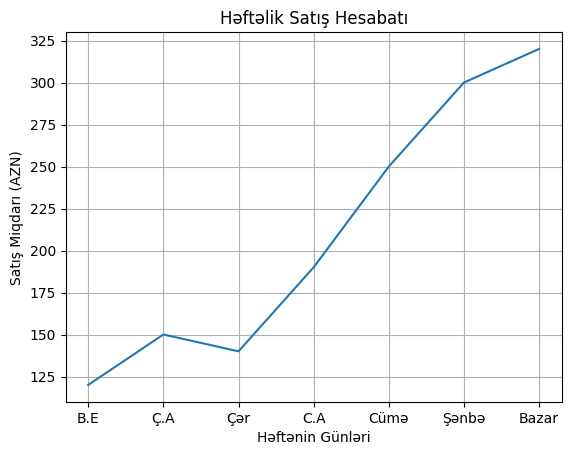

In [34]:
# matplotlib Line chart 

import matplotlib.pyplot as plt

# 1. Məlumat (Data)
gunler = ['B.E', 'Ç.A', 'Çər', 'C.A', 'Cümə', 'Şənbə', 'Bazar']
satislar = [120, 150, 140, 190, 250, 300, 320]

# 2. Qrafiki çəkmək (Line Plot - Xətti qrafik)
plt.plot(gunler, satislar)

# 3. Bəzəmək (Çox vacibdir! Etiketsiz qrafik heç kimə lazım deyil)
plt.title("Həftəlik Satış Hesabatı")  # Başlıq
plt.xlabel("Həftənin Günləri")        # X oxunun adı
plt.ylabel("Satış Miqdarı (AZN)")     # Y oxunun adı
plt.grid(True)                        # Arxa fona tor (grid) əlavə et

# 4. Ekrana vermək
plt.show()

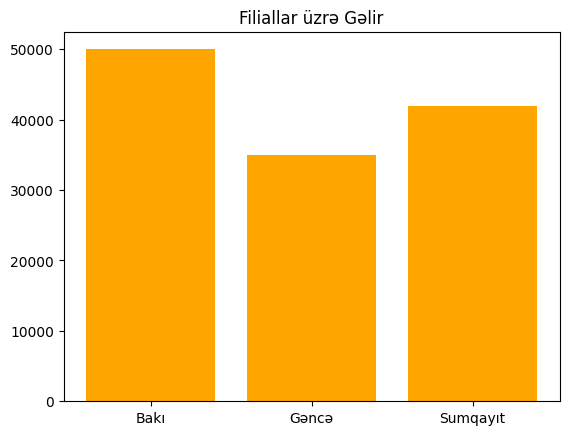

In [35]:
# bar

filiallar = ['Bakı', 'Gəncə', 'Sumqayıt']
gelir = [50000, 35000, 42000]

plt.bar(filiallar, gelir, color='orange') # Rəngi narıncı etdik
plt.title("Filiallar üzrə Gəlir")
plt.show()

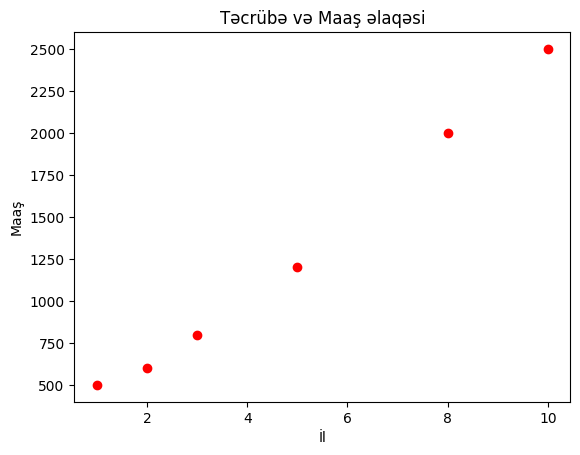

In [36]:
# Scatter

tecrube = [1, 2, 3, 5, 8, 10]
maas = [500, 600, 800, 1200, 2000, 2500]

plt.scatter(tecrube, maas, color='red', marker='o') # marker='o' nöqtə deməkdir
plt.title("Təcrübə və Maaş əlaqəsi")
plt.xlabel("İl")
plt.ylabel("Maaş")
plt.show()

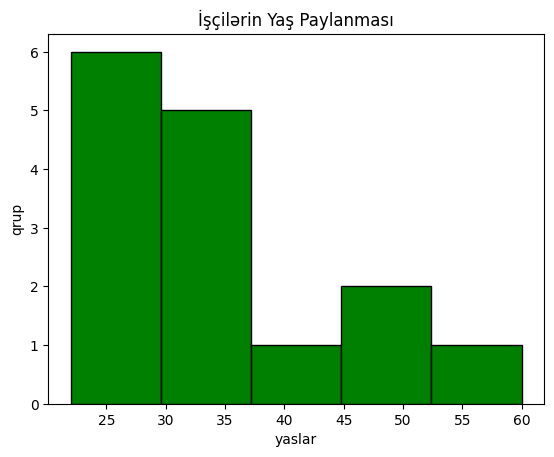

In [37]:
# Histogram 

yaslar = [22, 25, 25, 30, 30, 30, 35, 40, 45, 22, 23, 50, 60, 25, 30]

# bins=5 -> yaşları 5 bərabər aralığa böl
plt.hist(yaslar, bins=5, color='green', edgecolor='black')
plt.xlabel("yaslar")
plt.ylabel("qrup")
plt.title("İşçilərin Yaş Paylanması")
plt.show()

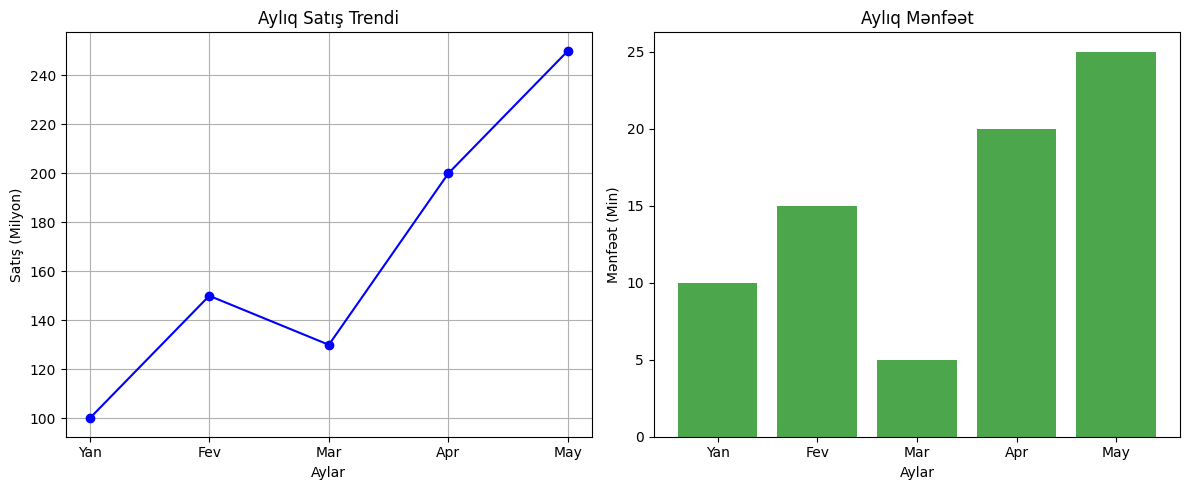

In [38]:


# 1. DATA (Məlumat)
aylar = ['Yan', 'Fev', 'Mar', 'Apr', 'May']
satis = [100, 150, 130, 200, 250]   # Satış məbləği
menfeet = [10, 15, 5, 20, 25]       # Qazanc (Mar-da düşüb)

# 2. ŞABLONU QURMAQ (Subplots)
# 1 sətir, 2 sütun. figsize=(eni, hündürlüyü)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Qrafik 1: Satış Trendi (Sol tərəf) ---
ax1.plot(aylar, satis, color='blue', marker='o')
ax1.set_title("Aylıq Satış Trendi")      # Diqqət: set_title
ax1.set_xlabel("Aylar")
ax1.set_ylabel("Satış (Milyon)")
ax1.grid(True)

# --- Qrafik 2: Mənfəət Sütunları (Sağ tərəf) ---
ax2.bar(aylar, menfeet, color='green', alpha=0.7)
ax2.set_title("Aylıq Mənfəət")
ax2.set_xlabel("Aylar")
ax2.set_ylabel("Mənfəət (Min)")

# 3. SƏLİQƏ (Layout)
# Bu kod qrafiklərin bir-birinə girməsinin qarşısını alır
plt.tight_layout()

# 4. GÖSTƏR
plt.show()

In [41]:
import pandas as pd

In [43]:
df = pd.read_excel(r'C:\Users\ACER\Desktop\task pandas.xlsx')
df

,ID,Tarix,Region,Məhsul,Satış Məbləği (AZN),Satılan Miqdar
0,1,2024-03-01,Bakı,Smartphone,1200,5
1,2,2024-03-01,Gəncə,Laptop,1500,2
2,3,2024-03-02,Bakı,Tablet,600,10
3,4,2024-03-02,Sumqayıt,Qulaqlıq,150,20
4,5,2024-03-03,Gəncə,Smartphone,1100,4
5,6,2024-03-03,Bakı,Laptop,1600,3
6,7,2024-03-04,Sumqayıt,Tablet,550,8
7,8,2024-03-04,Lənkəran,Qulaqlıq,140,15
8,9,2024-03-05,Bakı,Smartphone,1250,6
9,10,2024-03-05,Gəncə,Laptop,1450,2


In [44]:
# Yeni 'Tam Məbləğ' sütununun yaradılması
df['Tam Məbləğ'] = df['Satış Məbləği (AZN)'] * df['Satılan Miqdar']

# Nəticəyə baxmaq üçün
df

,ID,Tarix,Region,Məhsul,Satış Məbləği (AZN),Satılan Miqdar,Tam Məbləğ
0,1,2024-03-01,Bakı,Smartphone,1200,5,6000
1,2,2024-03-01,Gəncə,Laptop,1500,2,3000
2,3,2024-03-02,Bakı,Tablet,600,10,6000
3,4,2024-03-02,Sumqayıt,Qulaqlıq,150,20,3000
4,5,2024-03-03,Gəncə,Smartphone,1100,4,4400
5,6,2024-03-03,Bakı,Laptop,1600,3,4800
6,7,2024-03-04,Sumqayıt,Tablet,550,8,4400
7,8,2024-03-04,Lənkəran,Qulaqlıq,140,15,2100
8,9,2024-03-05,Bakı,Smartphone,1250,6,7500
9,10,2024-03-05,Gəncə,Laptop,1450,2,2900


In [45]:
# Ədədi orta (Sizə hər bir satışın orta hesabla neçə manat olduğunu deyir)
orta_mebleg = df['Tam Məbləğ'].mean()

# Standart kənarlaşma (Qiymətlərin ortalamadan nə qədər uzaqlaşdığını deyir)
std_mebleg = df['Tam Məbləğ'].std()

print(f"Orta Satış Məbləği: {orta_mebleg:.2f} AZN")
print(f"Standart Kənarlaşma: {std_mebleg:.2f} AZN")

Orta Satış Məbləği: 4495.00 AZN
Standart Kənarlaşma: 1404.77 AZN


In [46]:
# Pivot cədvəlinin yaradılması
pivot_df = df.pivot_table(index='Region', 
                          columns='Məhsul', 
                          values='Tam Məbləğ', 
                          aggfunc='sum',
                          fill_value=0) # Əgər həmin regionda o məhsul satılmayıbsa, NaN əvəzinə 0 yazır

print(pivot_df)

Məhsul    Laptop  Qulaqlıq  Smartphone  Tablet
Region                                        
Bakı        8100      4000       19400    6000
Gəncə       5900      2610        4400    5580
Lənkəran       0      2100        4600    4060
Sumqayıt    4650      3000        5200   10300
